In [3]:
# Import modules
import pandas as pd
import matplotlib.pyplot as plt
from fitter import Fitter
from scipy import stats


# Generate some data to use as input data

First we generate some sample using a random variate function to generate variates of a exponential distribution

<Axes: ylabel='Frequency'>

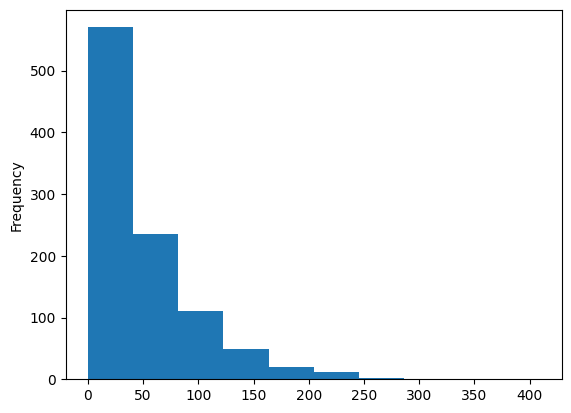

In [4]:
# load the data
dataset = pd.read_csv('dataset.csv',header=0)

dataset['time'].plot.hist()


# Selecting the appropiate distributions
One needs to select the potential distributions that could be suitanle for this data. Our input data corresponds to time. Hence, the nature of the process would require us to choose a continuous random variable. From the histograms we could supsect that the Gamma, Beta, and Exponential could suit this process. For the sake of illustration and discussion of the p-values we also consider the Normal and Erlang distributions.

        sumsquare_error           aic           bic    kl_div  ks_statistic  \
beta           0.000048   9759.891062   9779.522083  0.243759      0.016168   
erlang         0.000048   9759.386389   9774.109655  0.251982      0.018133   
gamma          0.000049   9760.190850   9774.914116  0.240152      0.019120   
expon          0.000054   9762.716888   9772.532399  0.227989      0.028268   
norm           0.000905  10609.172501  10618.988012  0.287835      0.159693   

           ks_pvalue  
beta    9.524554e-01  
erlang  8.913046e-01  
gamma   8.510688e-01  
expon   3.939171e-01  
norm    9.582737e-23  


2026-04-11 21:10:05.858 | INFO     | fitter.fitter:_fit_single_distribution:408 - Fitted norm: error=0.000905, AIC=10609.17, KS=0.1597
2026-04-11 21:10:05.872 | INFO     | fitter.fitter:_fit_single_distribution:408 - Fitted gamma: error=0.000049, AIC=9760.19, KS=0.0191
2026-04-11 21:10:05.875 | INFO     | fitter.fitter:_fit_single_distribution:408 - Fitted erlang: error=0.000048, AIC=9759.39, KS=0.0181
2026-04-11 21:10:05.889 | INFO     | fitter.fitter:_fit_single_distribution:408 - Fitted beta: error=0.000048, AIC=9759.89, KS=0.0162
2026-04-11 21:10:05.893 | INFO     | fitter.fitter:_fit_single_distribution:408 - Fitted expon: error=0.000054, AIC=9762.72, KS=0.0283
2026-04-11 21:10:05.899 | INFO     | fitter.fitter:_fit_single_distribution:408 - Fitted erlang: error=0.000048, AIC=9759.39, KS=0.0181


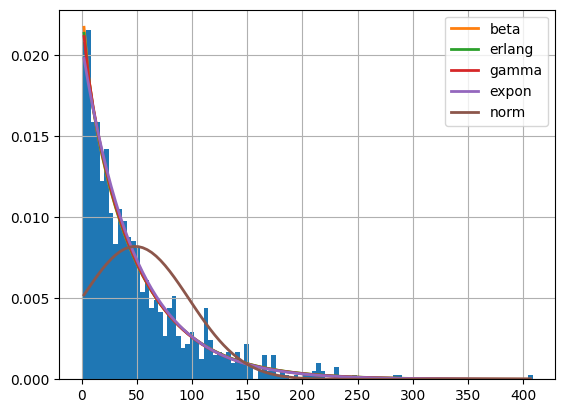

In [5]:
# Use fitter to fit distributions, you should select a subset after 
# exploring the histogram
fitDist = Fitter(dataset["time"], distributions =['norm', 'expon', 'gamma', 'erlang', 'beta', 'erlang'])
fitDist.fit()
print(fitDist.summary())

# Obtain the distribution parameters

Once one selects the distribution that is more appropiated, the estimated parameters must be retrieved and match them with JaamSim

In [6]:
# Print the parameters
print("Exponential parameters")
loc, scale = fitDist.fitted_param['expon']
print(f"location: {loc}, scale: {scale}","\n")

print("Erlang parameters")
shp1, loc, scale = fitDist.fitted_param['erlang']
print(f"shape: {shp1}, location: {loc}, scale: {scale}","\n")

shp1, shp2, loc, scale = fitDist.fitted_param['beta']
print("Beta parameters")
print(f"shape 1: {shp1}, shape 2: {shp2}, location: {loc}, scale: {scale}","\n")

shp1, loc, scale = fitDist.fitted_param['gamma']
print("Gamma parameters")
print(f"shape: {shp1}, location: {loc}, scale: {scale}","\n")

loc, scale = fitDist.fitted_param['norm']
print("Normal parameters")
print(f"location: {loc}, scale: {scale}","\n")

Exponential parameters
location: 0.2321392033171442, scale: 48.39315819494407 

Erlang parameters
shape: 0.9482028233851464, location: 0.23213920331714416, scale: 51.46973840091193 

Beta parameters
shape 1: 0.9337348750990389, shape 2: 72.73008161554088, location: 0.23213920331714416, scale: 3827.0632469532998 

Gamma parameters
shape: 0.9596112510791661, location: 0.23213920331714416, scale: 50.37242001086385 

Normal parameters
location: 48.62529739826122, scale: 48.60117547965986 



# Different fitting methods

Here we test the method of moments (mm) and the maximum-likelihood estimator (MLE)

In [7]:
# Testing the different methods for fitting
fitbeta = stats.gamma.fit(dataset,method="mm")
print(fitbeta)
fitbeta = stats.gamma.fit(dataset,method="MLE")
print(fitbeta)


(np.float64(1.1499696550821101), np.float64(-3.4929692628239835), np.float64(45.32142777051265))
(np.float64(0.9596112510791661), np.float64(0.23213920331714416), np.float64(50.37242001086385))


KSTest for expon
KS statistics = [0.02826799]
p-value = [0.39391713]
p-value = [10.35389911]
p-value = [1.]
p-value goodness_of_fit= 0.3966


<Axes: title={'center': 'Fitted $\\tt expon$ PDF and Histogram'}, xlabel='x', ylabel='PDF'>

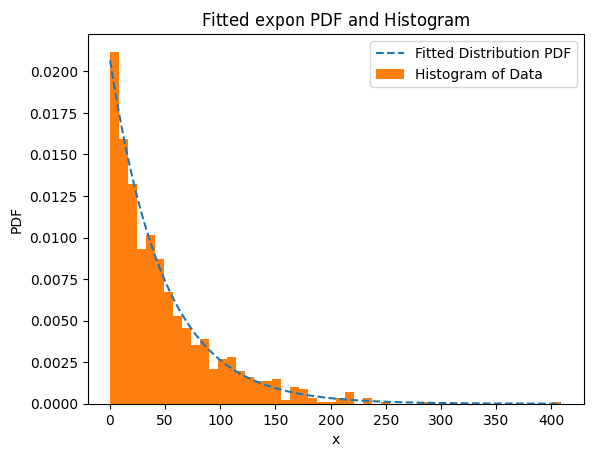

In [8]:
# KS test vs Aternative goodness of fit for Exponential
distChoice = 'expon'
ks_resutls = stats.kstest(
    dataset, 
    distChoice, 
    args=(fitDist.fitted_param[distChoice][0],
          fitDist.fitted_param[distChoice][1]))
print(f"KSTest for {distChoice}")
print(f"KS statistics = {ks_resutls.statistic}")
print(f"p-value = {ks_resutls.pvalue}")
print(f"p-value = {ks_resutls.statistic_location}")
print(f"p-value = {ks_resutls.statistic_sign}")

res= stats.goodness_of_fit(
    stats.expon, 
    dataset["time"], 
    known_params={'loc':fitDist.fitted_param[distChoice][0], 
                  'scale':fitDist.fitted_param[distChoice][1]},
                  statistic='ks')
print(f"p-value goodness_of_fit= {res.pvalue}")
plt.figure(3)
res.fit_result.plot()